# Plot Condensibility score

##### Project Description:

This is the very first batch of plot. I'm developing base on Sangwoo's data.

##### Working Directory:

/Volumes/BackupHaLab/condense-seq/ipython_notebooks/[Fig.1d]Condensibility_score.2026.ipynb

##### Start Date:

Jan 9, 2026

##### Editor:

Xin Lin

Here is the link to [Sangwoo's paper](https://www.nature.com/articles/s41586-025-08971-7)

In [1]:
# python modules
import sys, re
from collections import defaultdict
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
from scipy import stats

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Matplotlib:", mpl.__version__)
print("SciPy:", scipy.__version__)

# custom modules - Customized to BackupHaLab/
sys.path.append('/Volumes/BackupHaLab/condense-seq/postpro_scripts')
import graphics_edit as graphics
import load_file_edit as load_file
import Interval_dict_python3
import statis_edit as statis

Python: 3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]
NumPy: 2.2.6
Matplotlib: 3.10.7
SciPy: 1.14.1


In [2]:
# matplotlib setting
%matplotlib inline
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.facecolor"] = "white"
mpl.rcParams["savefig.facecolor"] = "white"


In [3]:
### parameters
cell_org = {'Exp1':'mouse',
            'Exp2':'mouse',
            'Exp3':'mouse'}

cell_chrnames = {'Exp1':['chr%s' % (i) for i in range(1, 20)] + ['chrX'],
                 'Exp2':['chr%s' % (i) for i in range(1, 20)] + ['chrX'],
                 'Exp3':['chr%s' % (i) for i in range(1, 20)] + ['chrX']}
# # DEBUG
# print(cell_chrnames)

In [4]:
### chromosome choices
chr_choices = cell_chrnames['Exp2']
# chr_choices = ['chr1', 'chr2', 'chr3']

## Loading files

Here are many files loaded into the working space

In [ ]:
### load gtab file
working_dir = "/Volumes/BackupHaLab/"
gtab_path = working_dir + "Oct2025_run/analysis_v2/"

dinfo_dkey = {
    'Exp1-Samp11_S2_score.gtab.gz': {'Exp1-Samp11_S2': (1, 'Exp1', 'score', 1)},
    # 'Exp1-Samp15_S3_score.gtab.gz': {'Exp1-Samp15_S3': (2, 'Exp1', 'score', 1)},
    # 'Exp2-Samp11_S5_score.gtab.gz': {'Exp2-Samp11_S5': (1, 'Exp2', 'score', 1)},
    # 'Exp2-Samp15_S6_score.gtab.gz': {'Exp2-Samp15_S6': (2, 'Exp2', 'score', 1)},
    # 'Exp3-Samp11_S8_score.gtab.gz': {'Exp3-Samp11_S8': (1, 'Exp3', 'score', 1)},
    # 'Exp3-Samp15_S9_score.gtab.gz': {'Exp3-Samp15_S9': (2, 'Exp3', 'score', 1)},
    'Exp4-Samp11_S11_score.gtab.gz': {'Exp4-Samp11_S11': (1, 'Exp4', 'score', 1)},
    # 'Exp4-Samp15_S12_score.gtab.gz': {'Exp4-Samp15_S12': (2, 'Exp4', 'score', 1)},
    # 'Exp5-Samp11_S14_score.gtab.gz': {'Exp5-Samp11_S14': (1, 'Exp5', 'score', 1)},
    # 'Exp5-Samp15_S15_score.gtab.gz': {'Exp5-Samp15_S15': (2, 'Exp5', 'score', 1)},
    # 'Exp6-Samp11_S17_score.gtab.gz': {'Exp6-Samp11_S17': (1, 'Exp6', 'score', 1)},
    # 'Exp6-Samp15_S18_score.gtab.gz': {'Exp6-Samp15_S18': (2, 'Exp6', 'score', 1)},
    # 'E14_NCP_titr15_1rep_score.gtab.gz': {'E14_NCP_titr15_1rep': (2, 'E14_NCP', 'score', 1)},
    # 'E14_NCP_titr15_2rep_score.gtab.gz': {'E14_NCP_titr15_2rep': (2, 'E14_NCP', 'score', 2)},
    # 'E14_NCP_titr11_1rep_score.gtab.gz': {'E14_NCP_titr11_1rep': (1, 'E14_NCP', 'score', 1)},
    'E14_NCP_titr11_2rep_score.gtab.gz': {'E14_NCP_titr11_2rep': (1, 'E14_NCP', 'score', 2)},
}

# The following function is NOWHERE to be found...
chr_dkey_ID_value = load_file.read_gtab_batch(dinfo_dkey,
                                               data_path=gtab_path,
                                               chr_choices=chr_choices,
                                               by_chr_first=True,
                                               verbal=True)
# print(list(chr_dkey_ID_value.items())[:5])

loading Exp1-Samp15_S3_score.gtab.gz
loading Exp4-Samp15_S12_score.gtab.gz
loading E14_NCP_titr15_2rep_score.gtab.gz
Done


In [6]:
### read G_banding file
gband_path = working_dir + 'condense-seq/data/MouseEpigeneticData/Gband/'
gband_fname = gband_path + 'Gband_mouse.txt'
chr_GID_Gband = load_file.read_Gband(gband_fname)

In [7]:
### read genome size
ref_path = working_dir + '/genomes/mm10/Bowtie2Index/'
ref_fname = ref_path + 'genome.fa'
genome_size = load_file.read_genome_size(ref_fname,
                                         chr_choices=chr_choices)
print(f"DEBUG: the first five elements in genome_size dict: {list(genome_size.items())[:5]}")

DEBUG: the first five elements in genome_size dict: [('chr10', 130694993), ('chr11', 122082543), ('chr12', 120129022), ('chr13', 120421639), ('chr14', 124902244)]


In [8]:
### read RNA-seq data
# (Jan 9, 2026: Vio replied it's the E14 cell line.)
RNAseq_path = working_dir + 'condense-seq/data/MouseEpigeneticData/E14_RNAseq/'
RNAseq_fname = 'ENCFF827OZU.tsv'
geneID_FPKM = load_file.read_ENCODE_RNA_seq(RNAseq_path + RNAseq_fname)

# DEBUG - confirming the input is valid
print(f"DEBUG: the first five elements in RNA-seq data: {list(geneID_FPKM.items())[-5:]}")

DEBUG: the first five elements in RNA-seq data: [('gSpikein_ERCC-00165', 0.0), ('gSpikein_ERCC-00168', 0.0), ('gSpikein_ERCC-00170', 0.0), ('gSpikein_ERCC-00171', 0.0), ('gSpikein_phiX174', 0.0)]


In [9]:
### read GTF file
GTF_path = working_dir + 'condense-seq/data/MouseEpigeneticData/GTF/'
GTF_fname = 'ENCFF871VGR.gtf'
geneID_field_value = load_file.read_GTF(GTF_path + GTF_fname,
                                         chr_list=chr_choices)
print(list(geneID_field_value.items())[:5])

[('ENSMUSG00000102693', {'chr': 'chr1', 'strand': '+', 'geneType': 'TEC', 'geneName': '4933401J01Rik', 'TSS': 3073252, 'TTS': 3074321, 'txps': {'ENSMUST00000193812': {'TSS': 3073252, 'TTS': 3074321, 'exons': [(3073252, 3074321)]}}, 'exons': [(3073252, 3074321)]}), ('ENSMUSG00000064842', {'chr': 'chr1', 'strand': '+', 'geneType': 'snRNA', 'geneName': 'Gm26206', 'TSS': 3102015, 'TTS': 3102124, 'txps': {'ENSMUST00000082908': {'TSS': 3102015, 'TTS': 3102124, 'exons': [(3102015, 3102124)]}}, 'exons': [(3102015, 3102124)]}), ('ENSMUSG00000051951', {'chr': 'chr1', 'strand': '-', 'geneType': 'protein_coding', 'geneName': 'Xkr4', 'TSS': 3671497, 'TTS': 3205900, 'txps': {'ENSMUST00000162897': {'TSS': 3216343, 'TTS': 3205900, 'exons': [(3213608, 3216343), (3205900, 3207316)]}, 'ENSMUST00000159265': {'TSS': 3215631, 'TTS': 3206522, 'exons': [(3213438, 3215631), (3206522, 3207316)]}, 'ENSMUST00000070533': {'TSS': 3671497, 'TTS': 3214481, 'exons': [(3670551, 3671497), (3421701, 3421900), (3214481, 3

In [10]:
### read titration file
titr_path = working_dir + 'Oct2025_run/analysis_v2/titration_files/'
titr_fname = 'Exp2-titration.tsv'
tnum_conc, tnum_frac = load_file.read_titration (titr_path + titr_fname)
print(tnum_conc, tnum_frac)

{0: 0.0, 1: 0.316227766, 2: 0.794328235} {0: 1.0, 1: 0.462825279, 2: 0.423791822}


In [11]:
### figure parameters
# set figure binning parameters
i = 20
bin_size = int(0.5*(10**6) / i) # binsize (unit of bp)
bin_step = bin_size # no overlap
blur_win = int(4*i + 1) # sliding window (unit of bin)

In [12]:
### binning/smoothing the condense-seq data
chr_dkey_sig = {}
for chr in chr_dkey_ID_value:
    for dkey in chr_dkey_ID_value[chr]:
        ID_value = chr_dkey_ID_value[chr][dkey]
        ID_loc = {ID:ID[1:] for ID in ID_value}
        max_pos = genome_size[chr]

        binID_mean = statis.rbin_data_mean(bin_size=bin_size,
                                           bin_step=bin_step,
                                           ID_loc=ID_loc,
                                           ID_value=ID_value,
                                           max_pos=max_pos,
                                           silent=True)

        sig = [binID_mean[binID] for binID in sorted(binID_mean.keys())]
        sig = statis.slow_moving_average2(sig, blur_win)

        if chr not in chr_dkey_sig:
            chr_dkey_sig[chr] = {}
        chr_dkey_sig[chr][dkey] = sig


hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash functi

In [13]:
### rescale/reorganize the RNA-seq data
chr_geneID_pos = {}
chr_geneID_logFPKM = {}
min_FPKM = min(geneID_FPKM.values())
for geneID in geneID_FPKM:
    try:
        chr = geneID_field_value[geneID]['chr']
        pos = geneID_field_value[geneID]['TSS']
    except:
        continue

    if chr not in chr_geneID_pos:
        chr_geneID_pos[chr] = {}
    chr_geneID_pos[chr][geneID] = pos

    logFPKM = np.log2(geneID_FPKM[geneID] - min_FPKM + 1)
    if chr not in chr_geneID_logFPKM:
        chr_geneID_logFPKM[chr] = {}
    chr_geneID_logFPKM[chr][geneID] = logFPKM
    

In [14]:
### binning/smoothing the RNA-seq data
chr_RNA_sig = {}
for chr in chr_choices:
    geneID_pos = chr_geneID_pos[chr]
    geneID_logFPKM = chr_geneID_logFPKM[chr]
    max_pos = genome_size[chr]
    binID_mean = statis.rbin_data_mean(bin_size,
                                       bin_step,
                                       geneID_pos,
                                       geneID_logFPKM,
                                       max_pos=max_pos,
                                       silent=True)

    sig = []
    for binID in sorted(binID_mean.keys()):
        mean = binID_mean[binID]
        if np.isnan(mean):
            mean = 0.0 # put zero expression when no gene found
        sig.append(mean)

    sig = statis.slow_moving_average2(sig, blur_win)
    chr_RNA_sig[chr] = sig


hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built


In [15]:
### binning the G-banding data
chr_binID_GID = {}
chr_GID_binwin = {}

for chr in chr_choices:
    GID_Gband = chr_GID_Gband[chr]

    Int_dict_Gband = Interval_dict_python3.bin_hash(
        ID_interval=None,        # <-- REQUIRED, first arg
        bin_size=bin_size,
        bin_step=bin_step,
        max_pos = genome_size[chr])

    binID_GIDs = {}
    for GID in GID_Gband:
        st, ed = GID_Gband[GID]['interval']
        find_binIDs = Int_dict_Gband.insert_range(st, ed, 1)
        binID_value = Int_dict_Gband.get()
        for binID in find_binIDs:
            binID_GIDs.setdefault(binID, []).append((binID_value.get(binID, 0), GID))
        Int_dict_Gband.ID_value.clear()   # <-- since bin_hash has no clear()

    binID_GID = {}
    GID_binIDs = {}
    for binID, GIDs in binID_GIDs.items():
        GID = sorted(GIDs, reverse=True)[0][1]
        binID_GID[binID] = GID
        GID_binIDs.setdefault(GID, []).append(binID)

    GID_binwin = {GID: (min(binIDs), max(binIDs)) for GID, binIDs in GID_binIDs.items()}

    chr_binID_GID[chr] = binID_GID
    chr_GID_binwin[chr] = GID_binwin


hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built
hash function is built


In [16]:
### make ideogram
chr_Gtype_ideogram = {}
for chr in chr_choices:
    GID_Gband = chr_GID_Gband[chr]
    Gtype_ideogram = {'num':[], 'var':[], 'acen':[]}
    binID_st, binID_ed = 0, genome_size[chr] // bin_step
    for binID in range(binID_st, binID_ed + 1):
        try:
            GID = chr_binID_GID[chr][binID]
            Gtype = GID_Gband[GID]['type']
            Gvalue = GID_Gband[GID]['value']
        except:
            for key in Gtype_ideogram:
                Gtype_ideogram[key].append([np.nan])
            continue

        if Gtype in ['neg', 'pos']:
            Gtype = 'num'
            assert not np.isnan(Gvalue)
        elif Gtype in ['var', 'acen']:
            Gvalue = 10
        else:
            pass
            
        for key in Gtype_ideogram:
            if key == Gtype:
                Gtype_ideogram[key].append([Gvalue])
            else:
                Gtype_ideogram[key].append([np.nan])

    chr_Gtype_ideogram[chr] = Gtype_ideogram

In [17]:
### set xtick labels along chromosome
chr_xtick_locs = {}
chr_xtick_labels = {}
for chr in chr_choices:
    xtick_locs, xtick_labels = [], []

    binID_st = 0
    binID_ed = genome_size[chr] // bin_step
    for binID in range(binID_st, binID_ed+1):
        pos = bin_step*binID + bin_size/2
        Mb_pos = int(round(float(pos)/(10**6)))

        if Mb_pos % 10 !=0: # 10Mbp steps
            continue

        label = str(Mb_pos)
        if label not in xtick_labels:
            xtick_locs.append(binID)
            xtick_labels.append(label)

    chr_xtick_locs[chr] = xtick_locs
    chr_xtick_labels[chr] = xtick_labels

In [18]:
#### set xtick labels for ideogram
chr_Gtick_locs = {}
chr_Gtick_labels = {}
for chr in chr_GID_binwin:
    GID_binwin = chr_GID_binwin[chr]
    Gtick_locs, Gtick_labels = [], []
    for GID in sorted(GID_binwin.keys()):
        binID_st, binID_ed = GID_binwin[GID]
        pos = (binID_st + binID_ed)/2
        Gname = chr_GID_Gband[chr][GID]['name']
        Gtick_locs.append(pos)
        Gtick_labels.append(Gname)
    chr_Gtick_locs[chr] = Gtick_locs
    chr_Gtick_labels[chr] = Gtick_labels

In [19]:
### set heterochromatin regions of ideogram
chr_shade_wins = {}
for chr in chr_GID_binwin:
    GID_binwin = chr_GID_binwin[chr]
    shade_wins = []
    for GID in sorted(GID_binwin.keys()):
        Gtype = chr_GID_Gband[chr][GID]['type']
        if Gtype =='pos':
            shade_wins.append(GID_binwin[GID])
    chr_shade_wins[chr] = shade_wins


In [20]:
### set mask region near centromere
chr_mask_wins = {}
for chr in chr_GID_binwin:
    GID_binwin = chr_GID_binwin[chr]
    mask_wins = []
    for GID in sorted(GID_binwin.keys()):
        Gtype = chr_GID_Gband[chr][GID]['type']
        if Gtype in ['var', 'acen']:
            mask_wins.append(GID_binwin[GID])

    # merge windows near next each others
    mask_wins = sorted(mask_wins)
    new_mask_wins = []
    for win in mask_wins:
        st, ed = win
        if not new_mask_wins:
            new_mask_wins.append((st, ed))
            continue
        prev_st, prev_ed = new_mask_wins.pop()
        if st - prev_ed <= 10:
            new_mask_wins.append((prev_st, max(prev_ed, ed)))
        else:
            new_mask_wins.append((prev_st, prev_ed))
            new_mask_wins.append((st, ed))

    # trim the first part of mask to match the reference genome
    for i in range(len(new_mask_wins)):
        st, ed = new_mask_wins[i]
        new_mask_wins[i] = (st+50, ed)
    
    chr_mask_wins[chr] = new_mask_wins

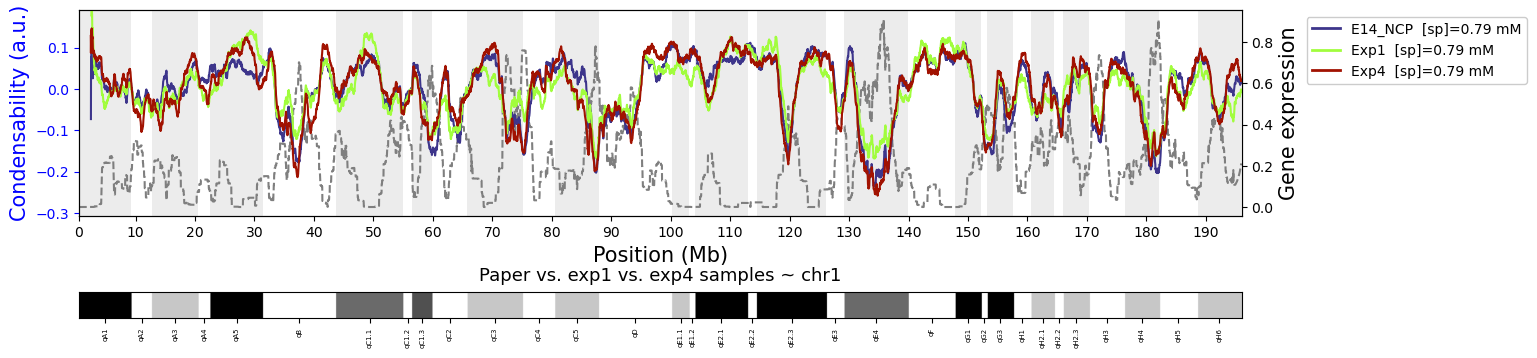

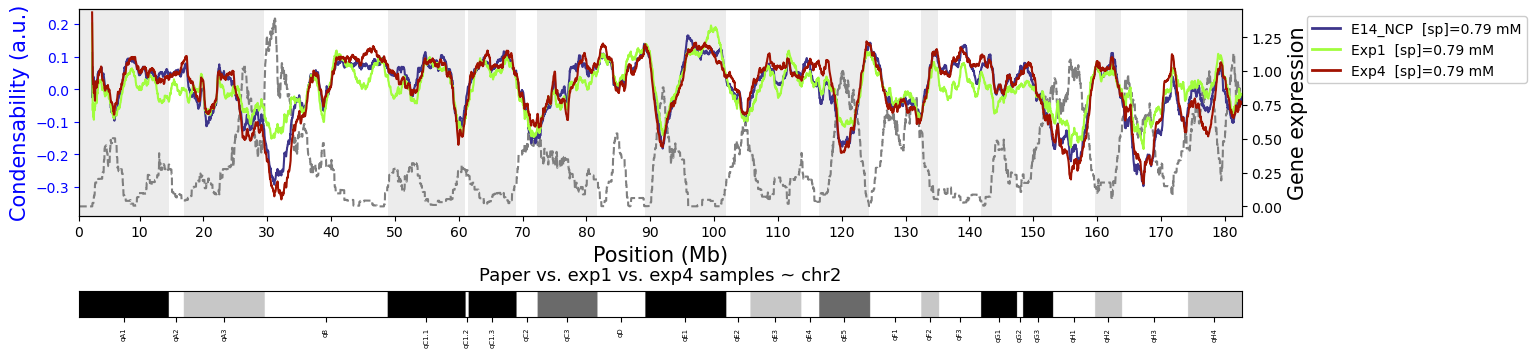

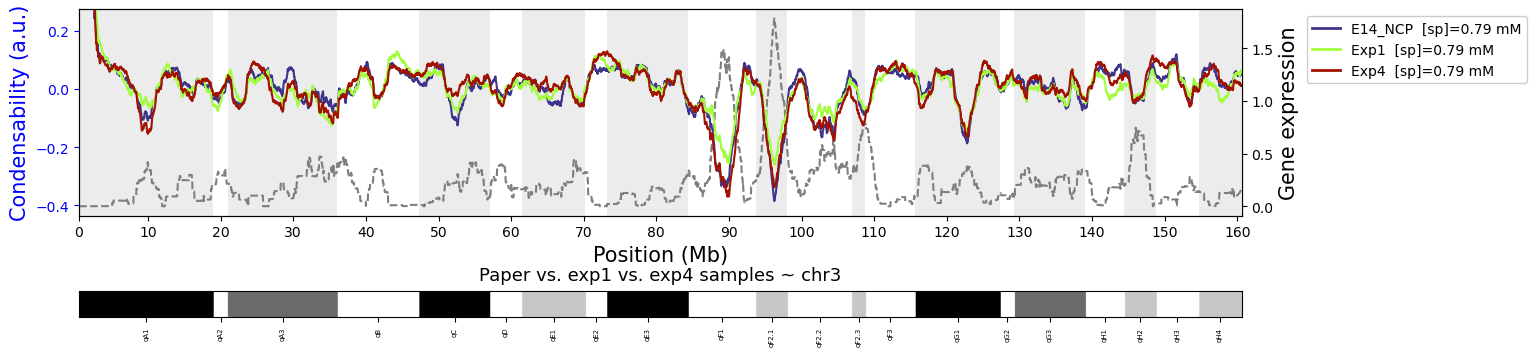

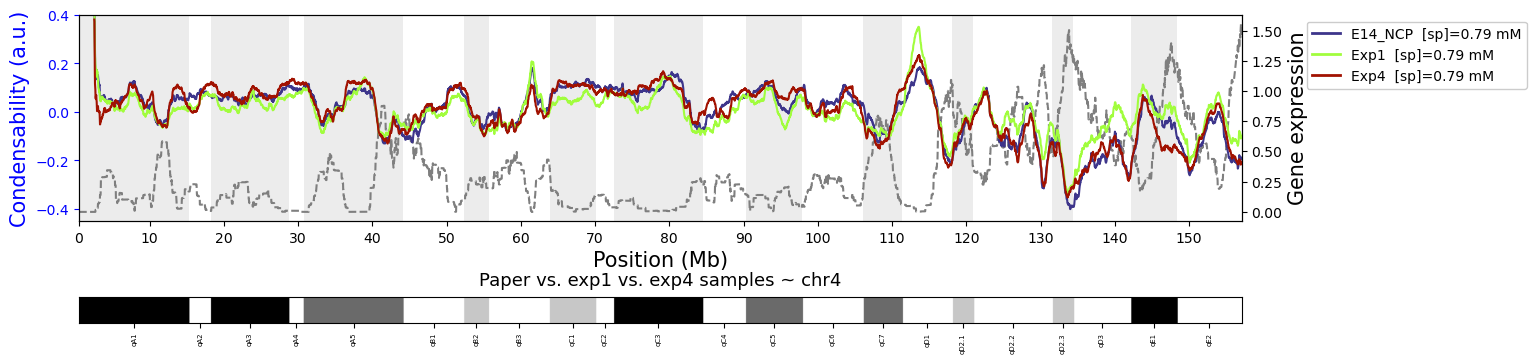

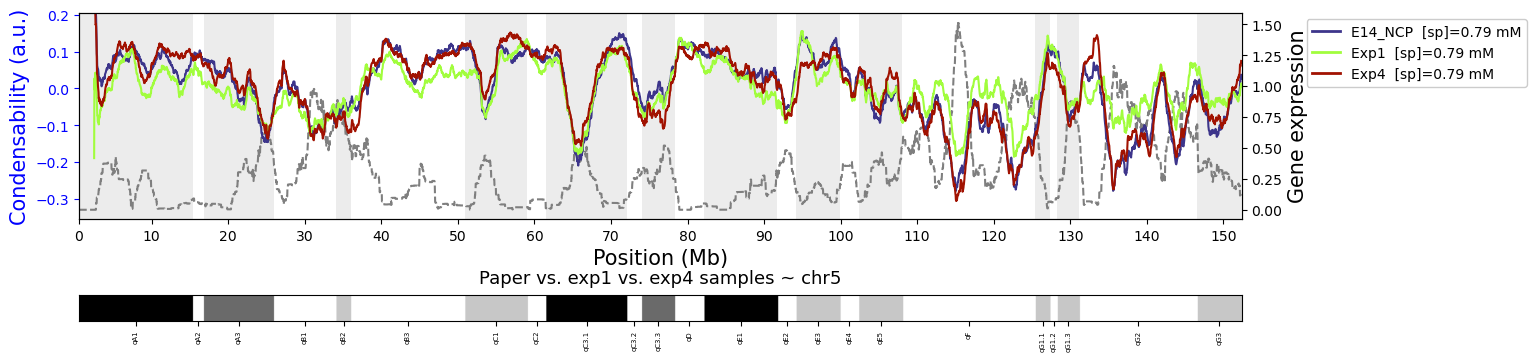

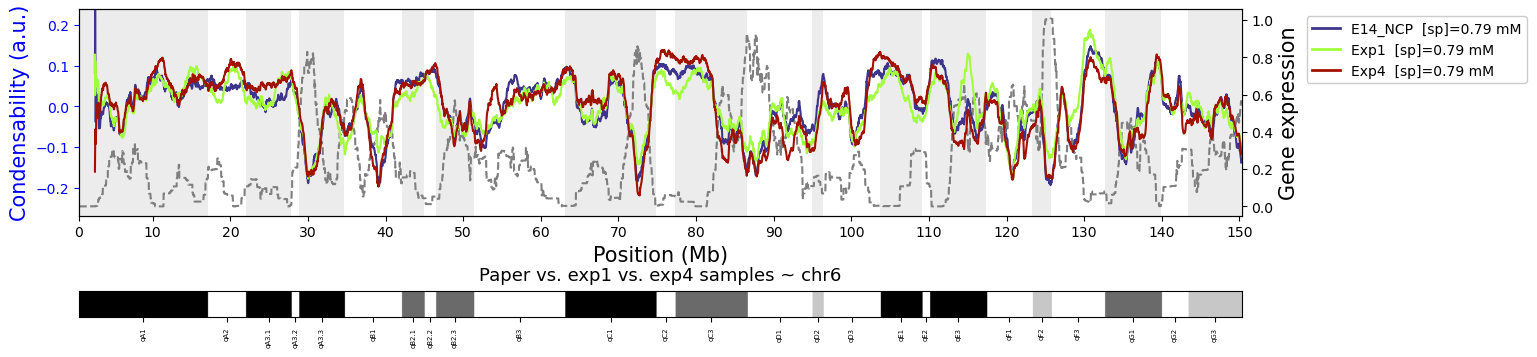

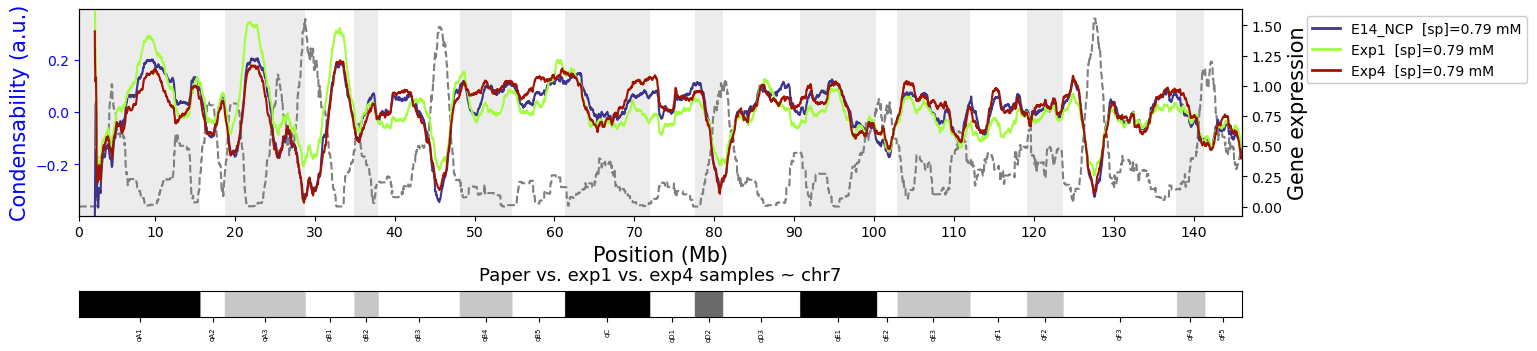

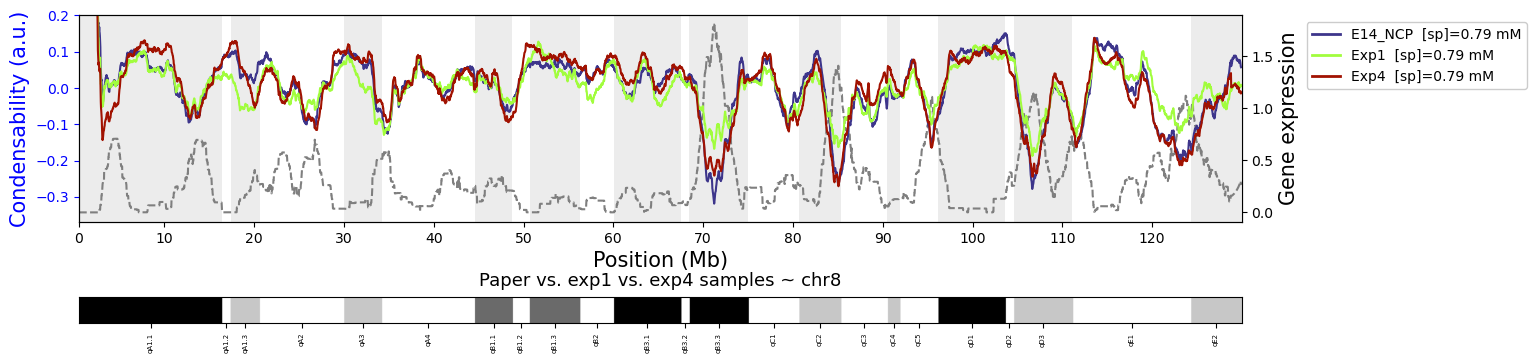

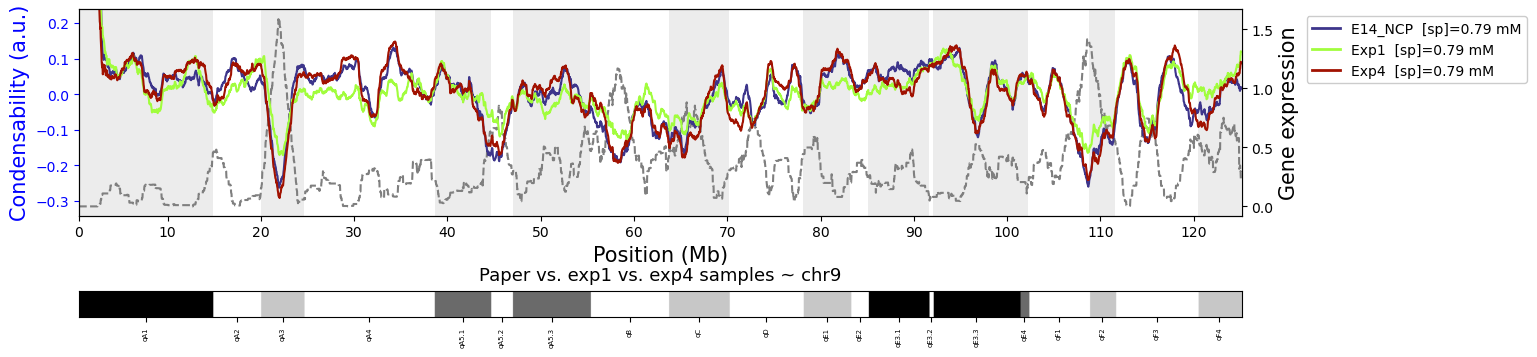

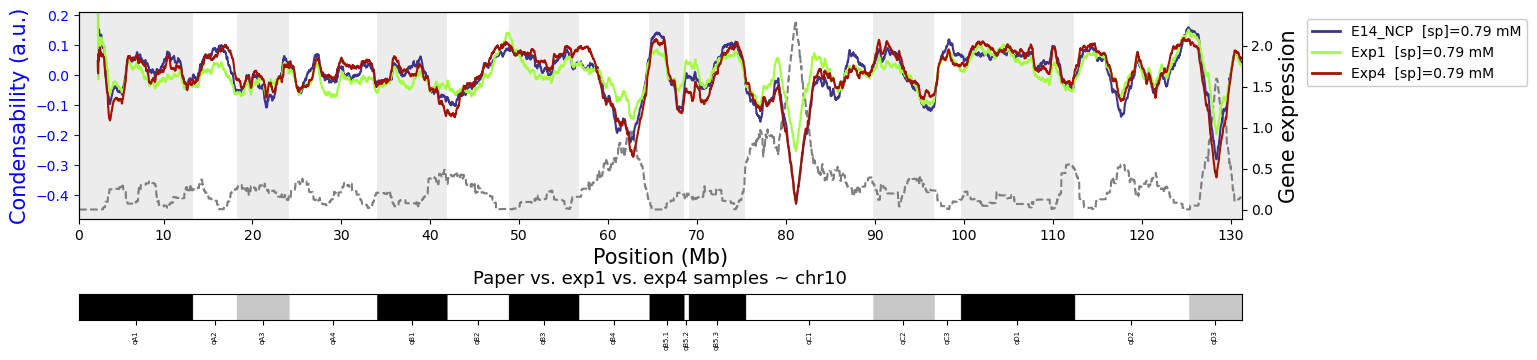

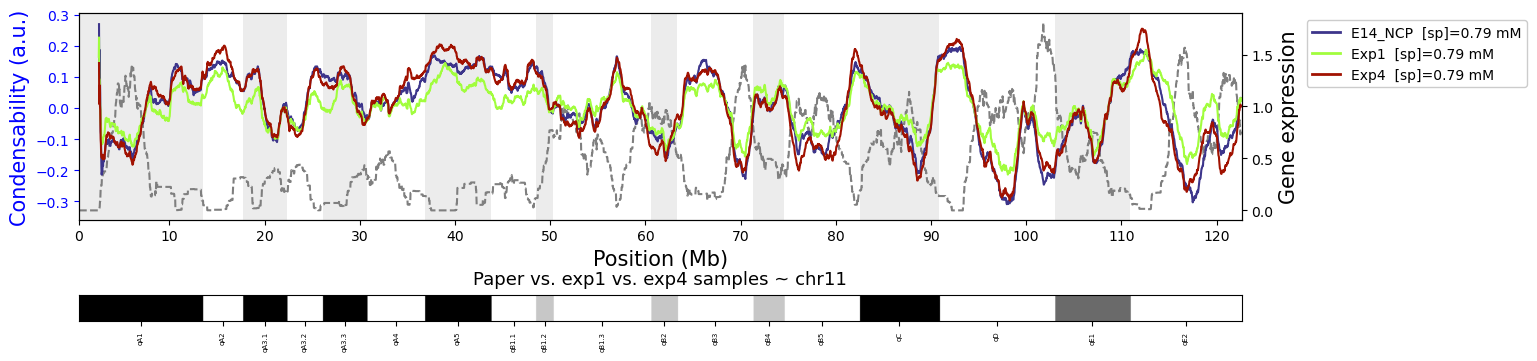

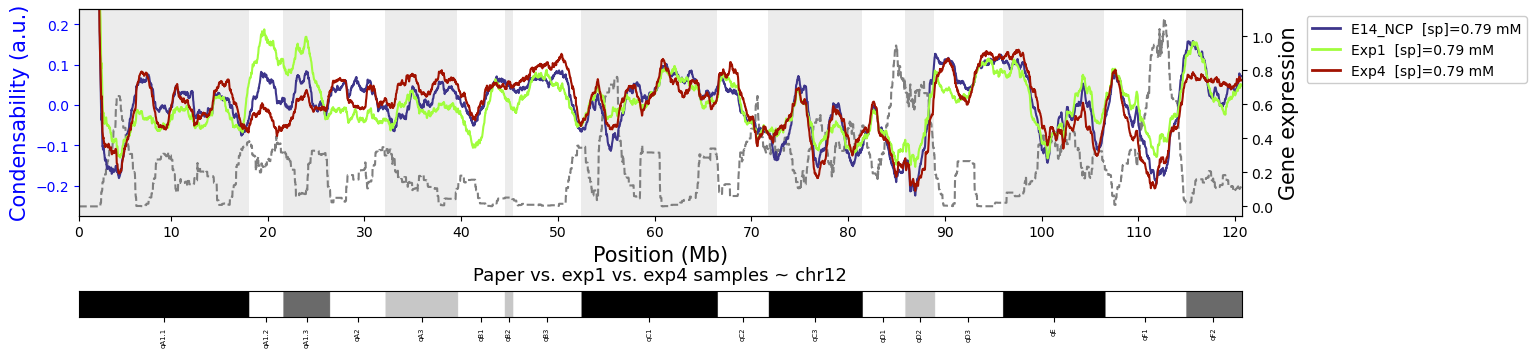

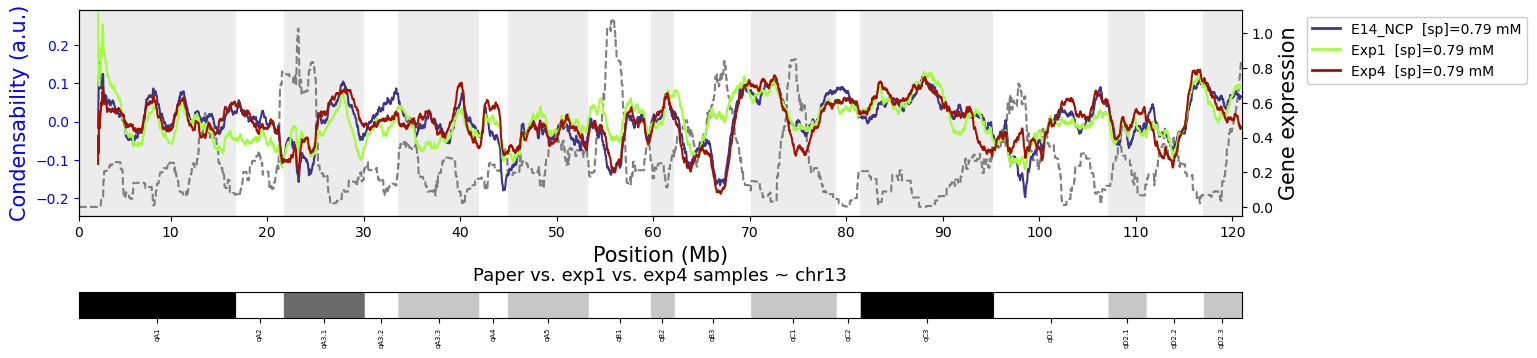

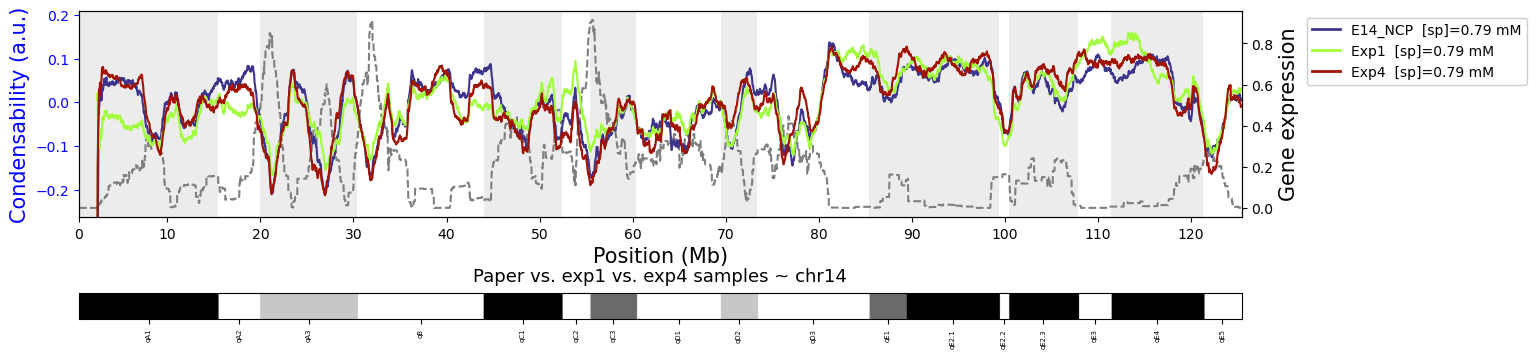

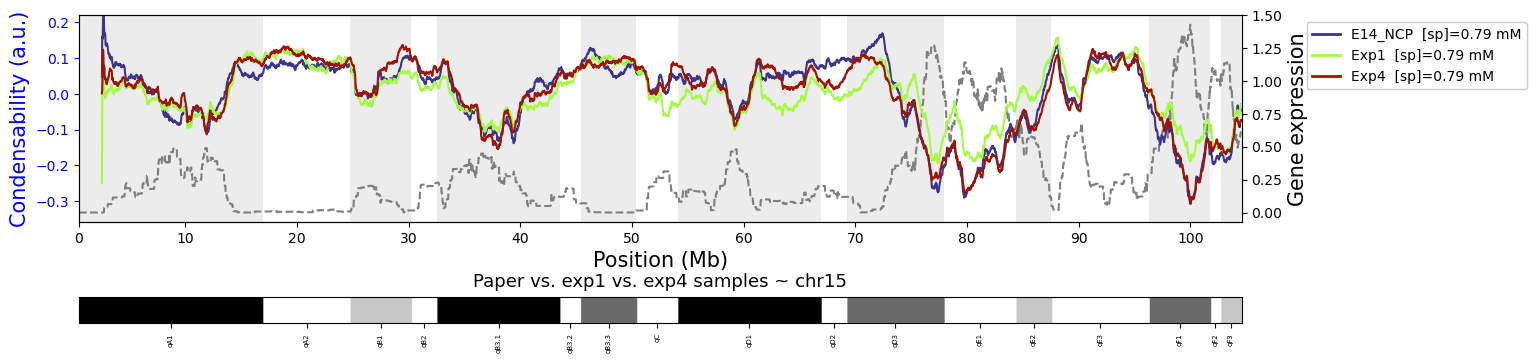

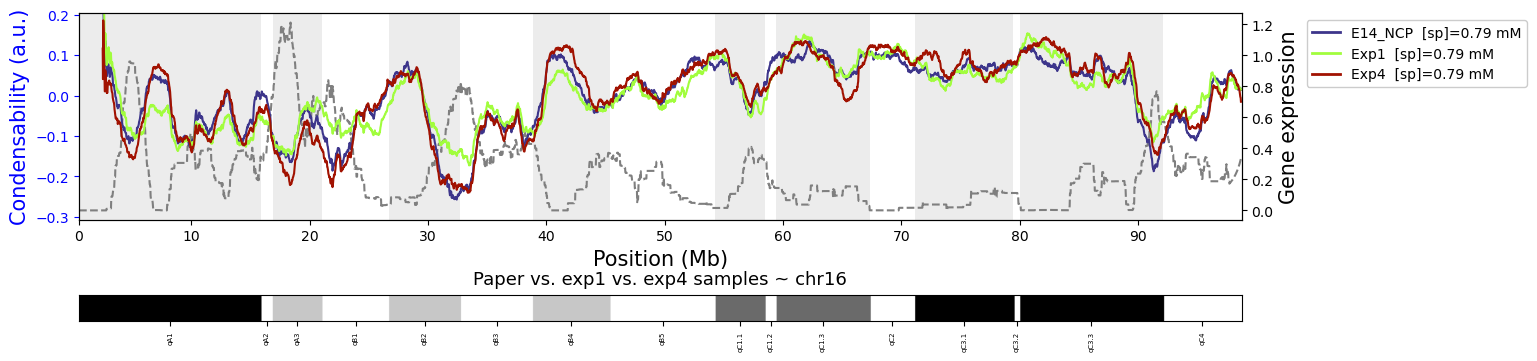

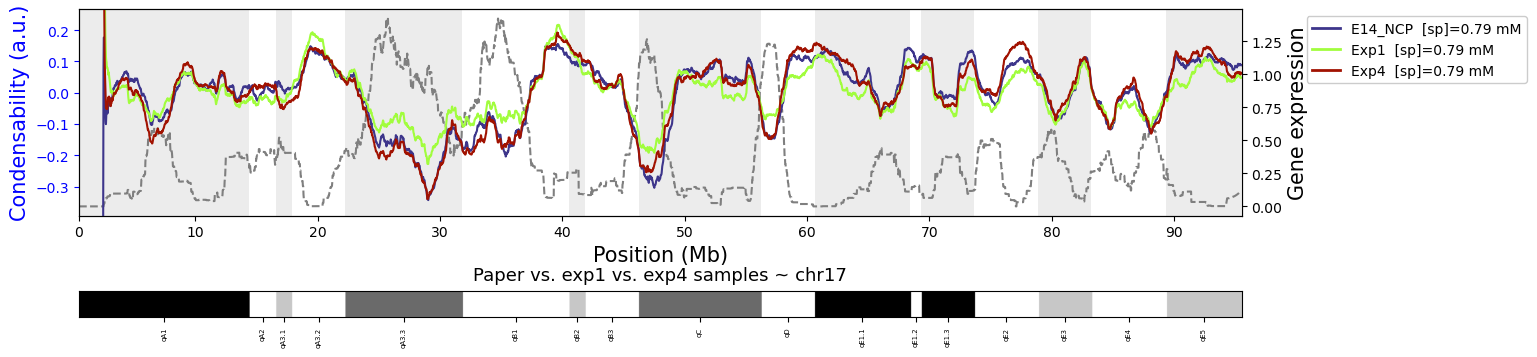

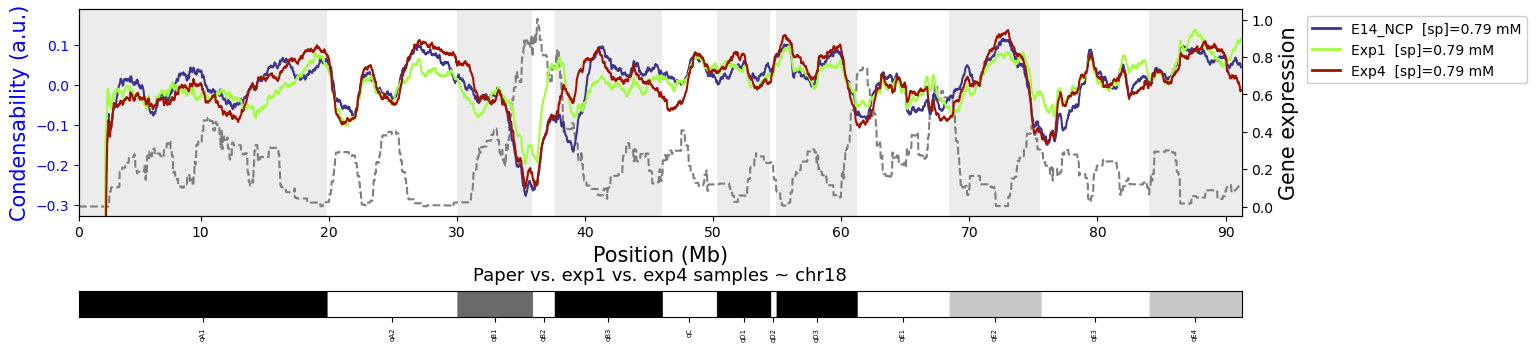

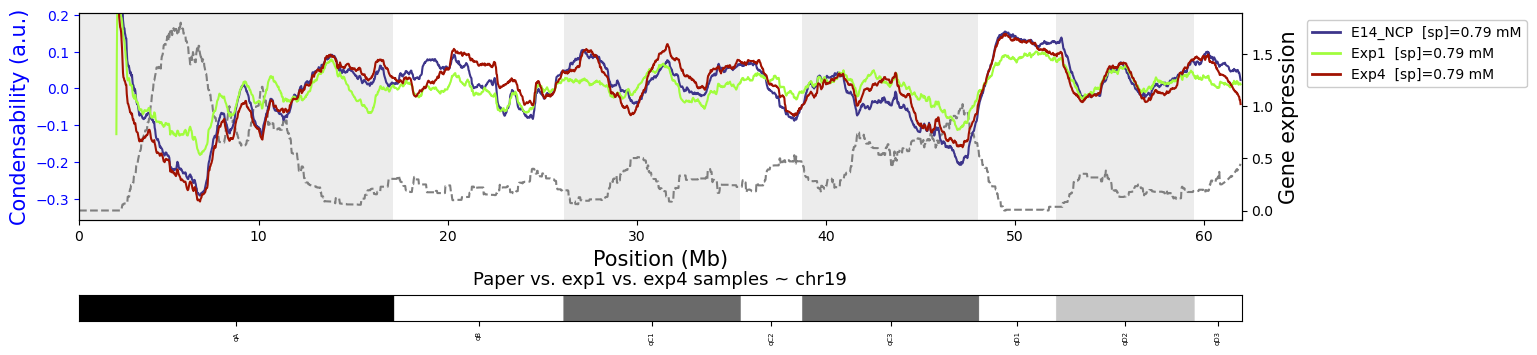

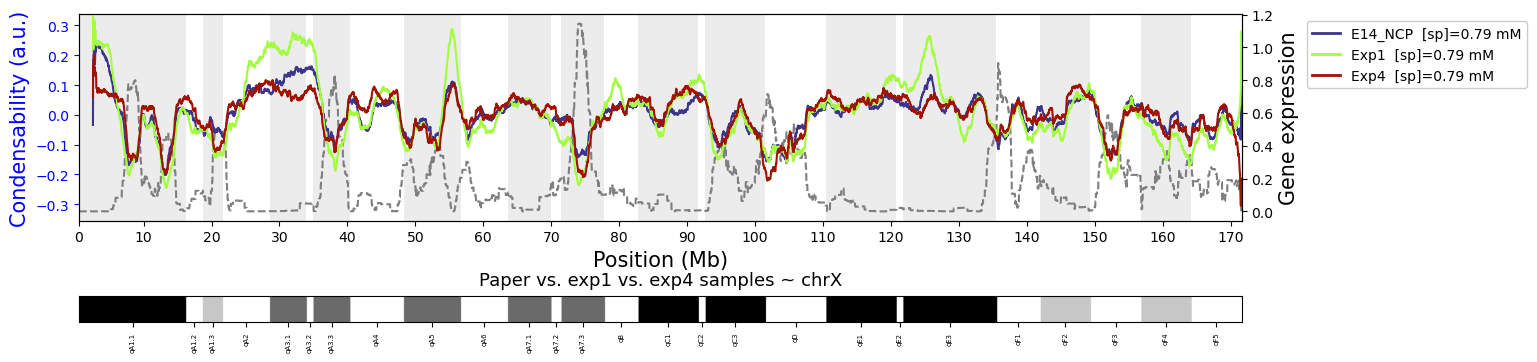

In [22]:
## plot data in genome-wide (condensability vs gene expression) [Fig.1d]
# ---- 1) dkey -> (exp, tnum) mapping (same as your working version) ----
sort_key_sample = lambda s: [int(x) for x in re.findall(r"\d+", s)] or [s]

exp_to_samples = defaultdict(list)
for _, inner in dinfo_dkey.items():
    for sample_name, dkey in inner.items():
        exp_to_samples[dkey[1]].append((sample_name, dkey))

dkey_to_group = {
    dkey: (exp, tnum)
    for exp, pairs in exp_to_samples.items()
    for tnum, (_, dkey) in enumerate(sorted(pairs, key=lambda x: sort_key_sample(x[0])))
}

# ---- 2) figure parameters ----
side_ylabel = {"left": "Condensability (a.u.)",
               "right": "Gene expression"}
side_ycolor = {"left": "blue",
               "right": "black"}

turbo = plt.get_cmap("turbo")

# ---- 3) plot per chromosome (stable) ----
for chr in chr_choices:
    # select dkeys present for this chromosome
    dkeys_chr = [dk for dk in chr_dkey_sig[chr] if dk in dkey_to_group]
    dkeys_chr.sort(key=lambda dk: (dkey_to_group[dk][0], dkey_to_group[dk][1]))
    
    # signals
    name_sig = {dk: statis.standardize(chr_dkey_sig[chr][dk], by_std=False)
                for dk in dkeys_chr}
    name_sig["RNA"] = chr_RNA_sig[chr]

    side_names = {"left": dkeys_chr, "right": ["RNA"]}
    
    # collect only condensability signals (exclude RNA)
    cond_sigs = [name_sig[dk] for dk in dkeys_chr]
    side_ylim = {
        "left": graphics.auto_ylim(
            cond_sigs,
            bin_step=bin_step,       # <-- you already have this
            min_pos_bp=2_500_000,    # ignore first 2.5 Mb
            base=(-0.2, 0.2),
            pad=0.05
        ),
        "right": None
    }

    # colors: each curve gets its own color
    xs = np.linspace(0.05, 0.95, max(len(dkeys_chr), 2))[:len(dkeys_chr)]
    name_color = {dk: turbo(x) for dk, x in zip(dkeys_chr, xs)}
    name_color["RNA"] = "black"

    name_alpha = {"RNA": 0.5}
    name_linestyle = {"RNA": "--"}

    # legend labels
    name_label = {}
    for dk in dkeys_chr:
        sample_idx, exp, sigtype, rep = dk  # sample_idx = 1 or 2
        conc = tnum_conc.get(sample_idx, None)
        if conc is None:
            name_label[dk] = f"{exp}  Sample#={sample_idx}"
        else:
            name_label[dk] = f"{exp}  [sp]={conc:.2f} mM"
    name_label["RNA"] = "RNA"


    # ---- plotting ----
    graphics.plot_genome_wide(
        side_names=side_names,
        name_sig=name_sig,
        name_color=name_color,
        name_alpha=name_alpha,
        name_label=name_label,
        name_linestyle=name_linestyle,
        side_ylabel=side_ylabel,
        side_ycolor=side_ycolor,
        side_ylim=side_ylim,
        xtick_locs=chr_xtick_locs[chr],
        xtick_labels=chr_xtick_labels[chr],
        Gtype_ideogram=chr_Gtype_ideogram[chr],
        Gtick_locs=chr_Gtick_locs[chr],
        Gtick_labels=chr_Gtick_labels[chr],
        shade_wins=chr_shade_wins[chr],
        mask_wins=chr_mask_wins[chr],
        legend_loc=(1.05, 1.0),   # outside, right
        fig_width=15,
        fig_height=4,
        height_ratios=[8, 1],
        hspace=0.65,
        save=False,
        show=True,
        note=f"Paper vs. exp1 vs. exp4 samples ~ {chr}"
    )